# **Running Aurora with GEFS-Control and GEFS-Aerosols Initial Conditions**


**[Microsoft Aurora](https://github.com/microsoft/aurora)** is a machine learning, foundational, model of the Earth system that has been pre-trained on various reanalysis and analysis datasets (i.e., ERA5, GFS, GEFS). To allow for *air pollution* forecasting, Aurora was fine-tuned on [CAMS](https://atmosphere.copernicus.eu/) Analysis and Reanalysis data spanning 2003 to 2022.

Despite being fine-tuned and intended for use with CAMS, we can replace some initial condition data from CAMS with corresponding data from [GEFS-Aerosols](https://www.arl.noaa.gov/research/surface-atmosphere-exchange-home/tools-and-products/gefs-aerosols/) and GEFS-Control meteorology and ozone. This allows us to explore Aurora's sensitivity to initial condition data and it's overall robustness at capturing air pollution episodes. The workflow for this code is visualized below...

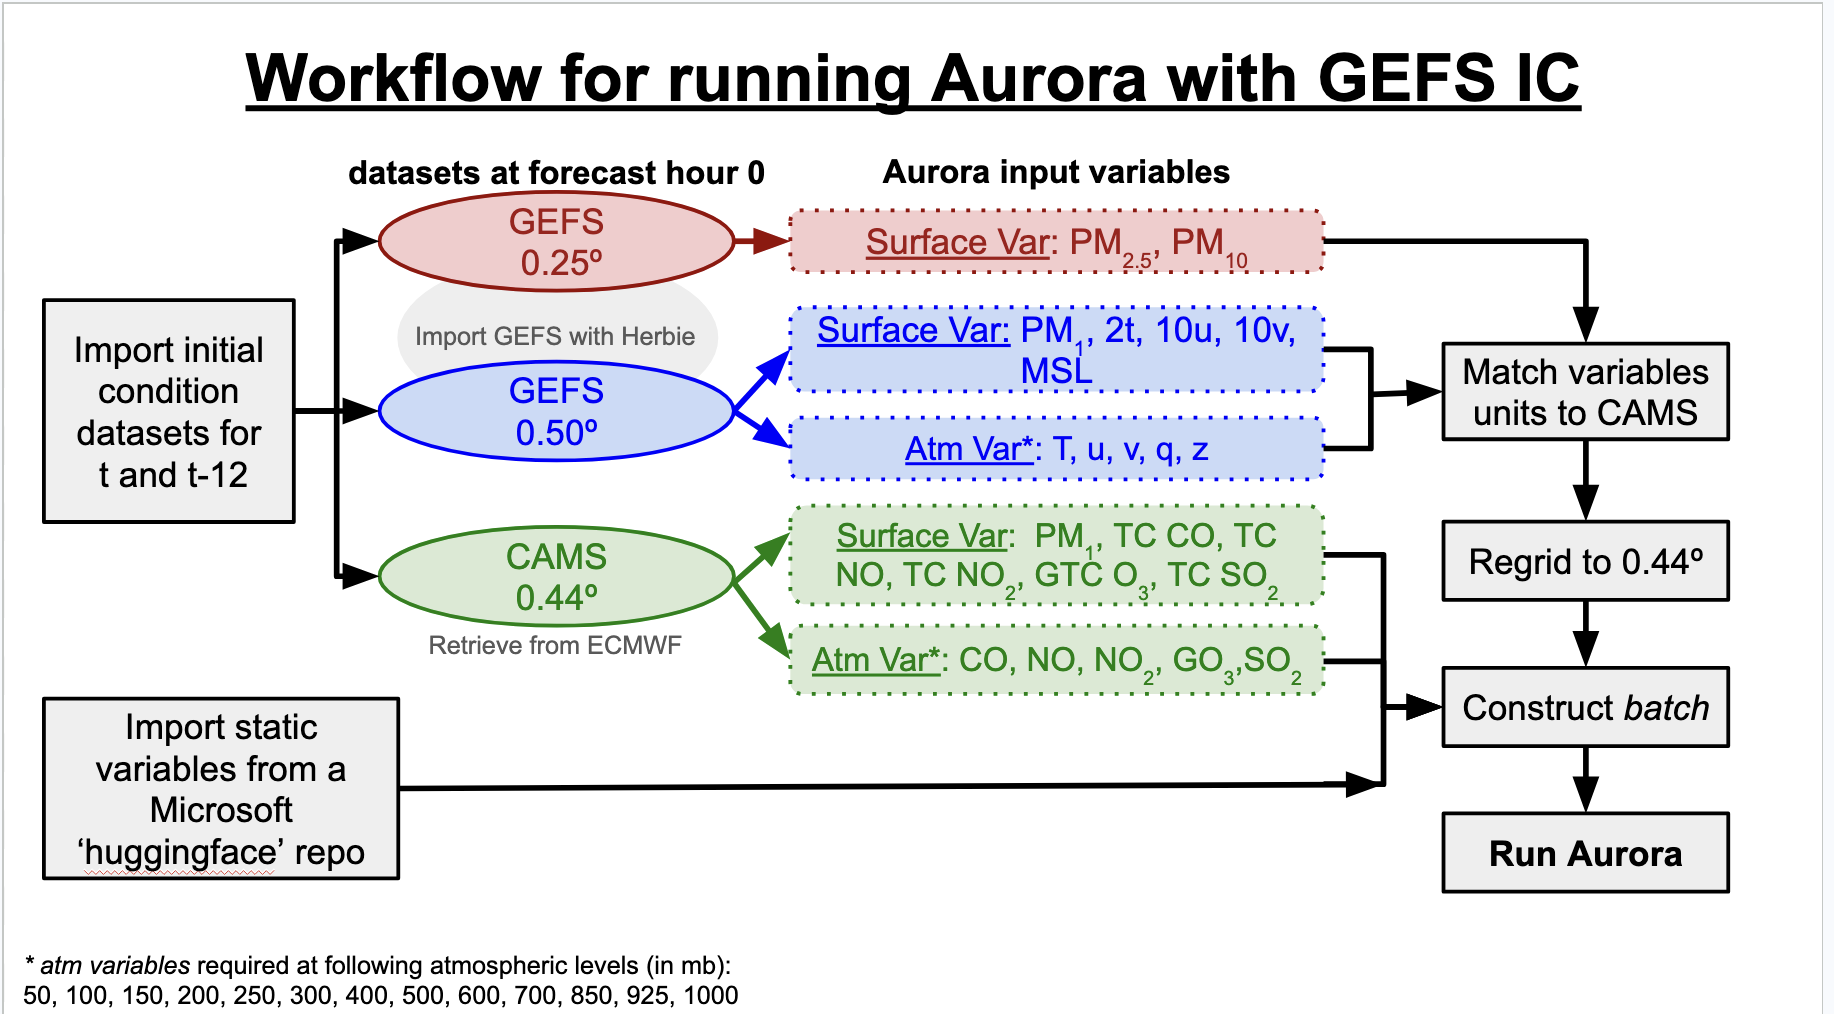


Regardless of data source, three datasets are needed as initial conditions for Aurora for batch creation.

*   **SURFACE** = meteorological variables at the surface
*   **ATMOSPHERE** = meteorological variables at various pressure levels
*   **STATIC** = variables that are dynamically fixed, in Air Pollution mode, this includes anthropogenic emissions and temporal predictors (i.e, DOY)

More information about batches can be found in [here](https://microsoft.github.io/aurora/batch.html)

## **Aurora variables**

Since Aurora was fine-tuned on CAMS data, we want to make sure variables exactly match in units, otherwise Aurora will hallucinate. Below are tables comparing the required variables; yellow indicates variables that will need to be converted from GEFS and red indicates variables missing from GEFS.

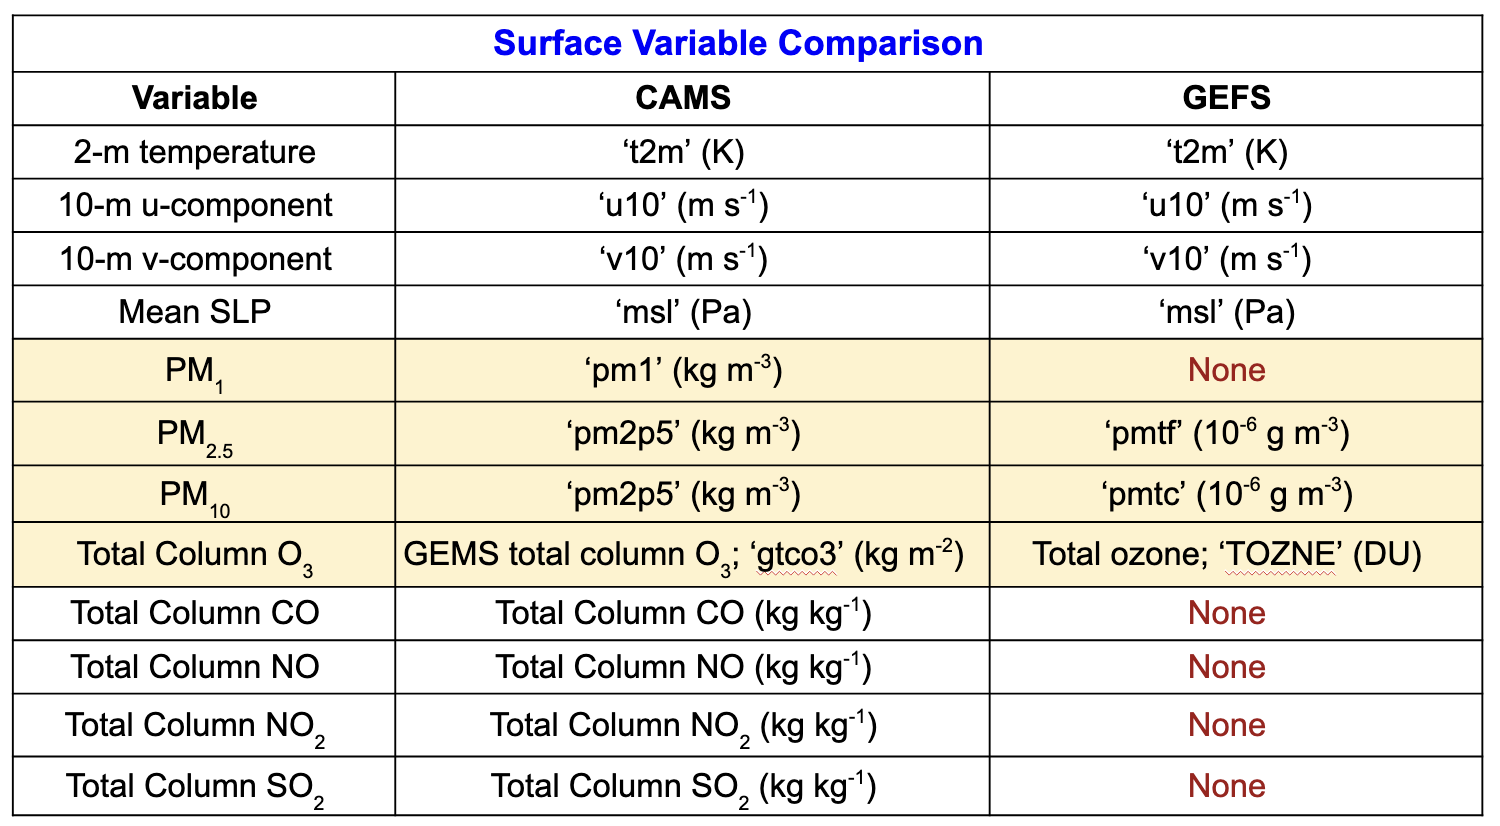

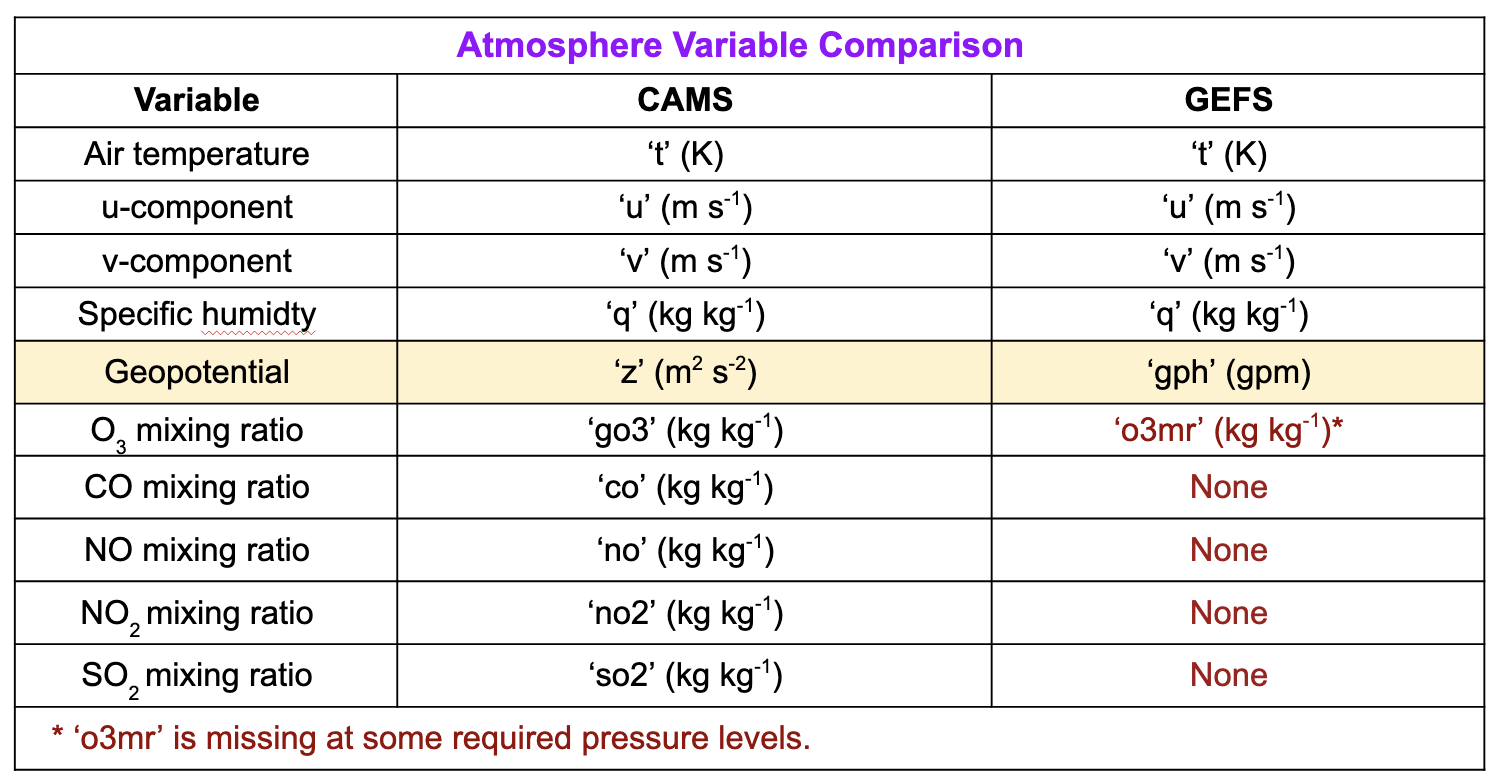

For simplicity, we will not use GEFS O3. Thus, CAMS trace gas data are used for all tested configurations of Aurora

In this notebook, we are targeting **surface PM2.5**


**🚩 IMPORTANT!! 🚩** In order to run Aurora, it is *highly* recommended that you connect to an A100 GPU or T4 otherwise Aurora may run out of RAM and crash. The high ram A100 GPU is not required, but can speed up run time if running forecasts over multiple days.



---



# **Configuring Environment**

In [ ]:
! git clone https://github.com/ehojeily/aurora_gefs

fatal: destination path 'aurora_gefs' already exists and is not an empty directory.


In [ ]:
# install Herbie; we will use this to retrieve GEFS data. Clone from this directory as a bug is fixed that allows GEFS-Chem 0.5deg data to be retrieved.
!git clone https://github.com/ehojeily/Herbie

fatal: destination path 'Herbie' already exists and is not an empty directory.


In [ ]:
# cfgrib is required to process grib files by Herbie
! pip install cfgrib

In [ ]:
# install cdsapi to retrieve CAMS data from the ECWMF API
!pip install cdsapi

In [ ]:
# install cartopy for plotting
! pip install cartopy

In [ ]:
# import remaining libraries
import zipfile
from pathlib import Path
import pickle
import torch
import xarray as xr
import pandas as pd
import xarray as xr
import sys
sys.path.append('/content/aurora_gefs/')
sys.path.append('/content/Herbie/src')
from aurora import Batch, Metadata
from aurora import AuroraAirPollution, rollout
from herbie import Herbie
import numpy as np
import shutil
import yaml
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec

import cdsapi

# **Set up forecast initialization information**

In [ ]:
forecast_initialization = '2025-04-12 12Z'
forecast_initialization = pd.to_datetime(forecast_initialization) # convert to datetime object

# **Importing CAMS and GEFS data**

**Retrieve CAMS Data**

**Note**: much of the code used here for the data retrieval was modified from the [Aurora Air Pollution demo script](https://microsoft.github.io/aurora/example_cams.html). Since ECMWF often is handling hundreds of data requests, it's easier to retrieve their data in bulk.

In [ ]:
# Store credenitals for accessing CAMS data
!echo url: https://ads.atmosphere.copernicus.eu/api > $HOME/.cdsapirc
!echo key: ENTER-YOUR-API-KEY-HERE >> $HOME/.cdsapirc ## REPLACE WITH YOUR API KEY for ECMWF ()
!cat $HOME/.cdsapirc

url: https://ads.atmosphere.copernicus.eu/api
key: 737d6151-4b11-4f1f-99a0-eadd9ab6e425


In [ ]:
# Download data for forecast initialization and last 12 hours
#   For the demo, start with 1 day. You'll need to import the previous 12 hours along with your day/time of interest.
date_start = forecast_initialization.strftime('%Y-%m-%d')
date_end = ((forecast_initialization) - pd.Timedelta(hours=12)).strftime('%Y-%m-%d') # retrieve previous 12 hours
# Construct the base filename using an f-string for better readability and correctness.
zip_filename = date_start+"-cams.nc.zip"
surface_level_filename = date_start+"-cams-surface-level.nc"
atmospheric_filename = date_start+"-cams-atmospheric.nc"

# Data will be downloaded here.
download_path = Path("/content/aurora_gefs/gefs/demo/data") # create a folder to store our demo data
download_path = download_path.expanduser()
download_path.mkdir(parents=True, exist_ok=True)

# Begin with installing forecast data
if not (download_path / zip_filename).exists():
    print(f'Retrieving ... {zip_filename}')
    c = cdsapi.Client()
    c.retrieve(
        "cams-global-atmospheric-composition-forecasts",
        {
            "type": "forecast",
            "leadtime_hour": ["0"], # feel free to add more lead times if you desire, forecast hour 0 is the analysis we need to initiaize Aurora
            "variable": [
                # Meteorological surface-level variables:
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
                "2m_temperature",
                "mean_sea_level_pressure",
                # Pollution surface-level variables:
                "particulate_matter_1um",
                "particulate_matter_2.5um",
                "particulate_matter_10um",
                "total_column_carbon_monoxide",
                "total_column_nitrogen_monoxide",
                "total_column_nitrogen_dioxide",
                "total_column_ozone",
                "total_column_sulphur_dioxide",
                # Meteorological atmospheric variables:
                "u_component_of_wind",
                "v_component_of_wind",
                "temperature",
                "geopotential",
                "specific_humidity",
                # Pollution atmospheric variables:
                "carbon_monoxide",
                "nitrogen_dioxide",
                "nitrogen_monoxide",
                "ozone",
                "sulphur_dioxide",
            ],
            "pressure_level": [
                "50",
                "100",
                "150",
                "200",
                "250",
                "300",
                "400",
                "500",
                "600",
                "700",
                "850",
                "925",
                "1000",
            ],
            "date": f"{date_start}/{date_end}",
            "time": ["00:00","12:00"],
            "format": "netcdf_zip",
        },
        str(download_path / zip_filename),
    )


Retrieving ... 2025-04-12-cams.nc.zip


2026-05-28 15:25:22,265 INFO Request ID is fde74582-7adf-4084-8862-03c73417e583
INFO:ecmwf.datastores.legacy_client:Request ID is fde74582-7adf-4084-8862-03c73417e583
2026-05-28 15:25:22,466 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-05-28 15:31:44,851 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-05-28 15:33:45,753 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


64f0bf378ddeec48e9370b839533908d.zip:   0%|          | 0.00/228M [00:00<?, ?B/s]

In [ ]:
# unpack our surface and atmospheric files
# files.
if not (download_path / surface_level_filename).exists():
    with zipfile.ZipFile(download_path / zip_filename, "r") as zf, open(
        download_path / surface_level_filename, "wb"
    ) as f:
        f.write(zf.read("data_sfc.nc"))
if not (download_path / atmospheric_filename).exists():
    with zipfile.ZipFile(download_path / zip_filename, "r") as zf, open(
        download_path / atmospheric_filename, "wb"
    ) as f:
        f.write(zf.read("data_plev.nc"))
print("Surface-level and atmospheric variables downloaded!")

Surface-level and atmospheric variables downloaded!


In [ ]:
# and create xarray datasets for our CAMS datasets

# xarray for our atmospheric variables from CAMS
atmos_vars_ds = xr.open_dataset(
    download_path / atmospheric_filename, decode_timedelta=True)
# xarray for our surface level variables from CAMS
surf_vars_ds = xr.open_dataset(
    download_path / surface_level_filename, decode_timedelta=True)

**Retrieving GEFS Data**

GEFS data are archived on AWS which allows for quick data retrievals. As such, we will import GEFS data as we need them while running Aurora. However, we will define a function that we need to import GEFS-Atmosphere data `retrieve_gefs_atmos` and another function to pull the PM1 data from GEFS 0.5deg ```approx_gefs_pm1```



In [ ]:
def retrieve_gefs_atmos(t,ensemble_member,variables,verbose=False):
  # for a specific time 't', this function returns GEFS-Atmos data at forecast hour 0 (analysis product).
  # this function will look into the GEFS 0.5 and 0.5b (secondary param) files to pull *only* data we require
  # == INPUTS ==
  # t = forecast hour we are interested in
  # variables = list of variables we want to retrieve from GEFS-Atmos
  # verbose = indicate if you want to be notified of what variables are retrieved and other useful print statements, good for debugging
  # == OUTPUTS ==
  # dictionaries containing data-arrays with requested surface and atmospheric variables

  if ensemble_member == 'c00':
    end_str = 'low-res ctl'
  if ensemble_member != 'c00':
    end_str = '+'+str(ensemble_member)

  H_t0b = Herbie(
      pd.to_datetime(t[0]).strftime('%Y-%m-%d %H'),
      model="gefs",
      product="atmos.5b",
      member=ensemble_member,
      fxx=00 # forecast hour
  )

  H_t0 = Herbie(
      pd.to_datetime(t[0]).strftime('%Y-%m-%d %H'),
      model="gefs",
      product="atmos.5",
      member=ensemble_member,
      fxx=00 # forecast hour
  )

  ds_list = [] # list of surf variables
  da_list = [] # list of atm variables

  # Retrieve TMP
  TMP_sfc = H_t0.xarray(r":TMP:2 m above ground:")
  var = 'TMP'
  TMP = H_t0.xarray("(?:"+var+":1000 mb|"+var+":925 mb|"+var+":850 mb|"+var+":700 mb|"+var+":500 mb|"+var+":250 mb|"+var+":100 mb|"+var+":50 mb)")
  TMP_b = H_t0b.xarray("(?:"+var+":600 mb|"+var+":400 mb|"+var+":300 mb|"+var+":150 mb)")
  # Append vars to list for concat
  ds_list.append(TMP_sfc)
  da_list.append(TMP)
  da_list.append(TMP_b)

  if verbose == True:
    print('retrieved: TMP')

  # Retrieve UGRD
  UGRD_sfc = H_t0.xarray(r":UGRD:10 m above ground:")
  var = 'UGRD'
  UGRD = H_t0.xarray("(?:"+var+":1000 mb|"+var+":925 mb|"+var+":850 mb|"+var+":700 mb|"+var+":500 mb|"+var+":400 mb|"+var+":300 mb|"+var+":250 mb|"+var+":200 mb|"+var+":100 mb|"+var+":50 mb)")
  UGRD_b = H_t0b.xarray("(?:"+var+":600 mb|"+var+":150 mb)")

  # Append vars to list for concat
  ds_list.append(UGRD_sfc)
  da_list.append(UGRD)
  da_list.append(UGRD_b)
  if verbose == True:
    print('retrieved: UGRD')

  # Retrieve VGRD
  VGRD_sfc = H_t0.xarray(r":VGRD:10 m above ground:")
  var = 'VGRD'
  VGRD = H_t0.xarray("(?:"+var+":1000 mb|"+var+":925 mb|"+var+":850 mb|"+var+":700 mb|"+var+":500 mb|"+var+":400 mb|"+var+":300 mb|"+var+":250 mb|"+var+":200 mb|"+var+":100 mb|"+var+":50 mb)")
  VGRD_b = H_t0b.xarray("(?:"+var+":600 mb|"+var+":150 mb)")


  # Append vars to list for concat
  ds_list.append(VGRD_sfc)
  da_list.append(VGRD)
  da_list.append(VGRD_b)
  if verbose == True:
    print('retrieved: VGRD')

  # Retrieve MSL
  PRMSL = H_t0.xarray(r":PRMSL")
  # Append vars to list for concat
  ds_list.append(PRMSL)
  if verbose == True:
    print('retrieved: PRMSL')

  # Retrieve O3MR & TZONE
  if 'O3MR' in variables:
    var = 'O3MR'
    O3MR = H_t0b.xarray("(?:"+var+":400 mb|"+var+":300 mb|"+var+":250 mb|"+var+":150 mb|"+var+":100 mb|"+var+":50 mb)")
    da_list.append(O3MR)
    if verbose == True:
      print('retrieved: O3MR')
  if 'TOZNE' in variables:
    TOZNE = H_t0b.xarray(r":TOZNE:")
    ds_list.append(TOZNE)
    if verbose == True:
      print('retrieved: TOZNE')


  # Retrieve SPFH
  var = 'SPFH'
  SPFH_b = H_t0b.xarray("(?:"+var+":1000 mb|"+var+":925 mb|"+var+":850 mb|"+var+":700 mb|"+var+":600 mb|"+var+":500 mb|"+var+":400 mb|"+var+":300 mb|"+var+":250 mb|"+var+":150 mb|"+var+":100 mb|"+var+":50 mb)")
  if verbose == True:
    print('retrieved: SPFH')
  # Append vars to list for concat
  da_list.append(SPFH_b)

  # Retrieve HGT
  var = 'HGT'
  HGT = H_t0.xarray("(?:"+var+":1000 mb|"+var+":925 mb|"+var+":850 mb|"+var+":700 mb|"+var+":500 mb|"+var+":300 mb|"+var+":250 mb|"+var+":100 mb|"+var+":50 mb)")
  HGT_b = H_t0b.xarray("(?:"+var+":600 mb|"+var+":400 mb|"+var+":150 mb)")
  if verbose == True:
    print('retrieved: HGT')
  # Append vars to list for concat
  da_list.append(HGT)
  da_list.append(HGT_b)

  # create files!
  ds_gefs_met = xr.merge(ds_list,compat='override', join='outer')
  da_gefs_met = xr.merge(da_list,compat='no_conflicts', join='outer')

  da_gefs_met = da_gefs_met.rename({'isobaricInhPa':'pressure_level'})
  da_gefs_met=da_gefs_met.sortby('pressure_level', ascending=False)
  da_gefs_met=da_gefs_met.sel(pressure_level = [1000,925,850,700,600,500,400,300,250,150,100,50])

  output_dict = {'ds_gefs_surf':ds_gefs_met, 'da_gefs_atmos':da_gefs_met}
  return output_dict

In [ ]:
def approx_gefs_pm1(t, verbose=False):
  # for a specific time 't', this function returns GEFS-Chem PM composition data
  # this function will look into the GEFS 0.5 files to pull *only* data we require at hybrid level 1
  # == INPUTS ==
  # t = forecast hour we are interested in
  # verbose = indicate if you want to be notified of what variables are retrieved and other useful print statements, good for debugging
  # == OUTPUTS ==
  # data-arrays with PM1 approximated as the sum of BC, OC, and sulphate

  H_t = Herbie(
    pd.to_datetime(t[0]).strftime('%Y-%m-%d %H'),
    model="gefs",
    product="chem.5",
    member="c00", # no need to specify a member here; GEFS-Aerosols only runs on the control!
    fxx=0)

  dpm1_list  = []
  pm_components = (list(H_t.inventory()[H_t.inventory()['level']=='1 hybrid level']['search_this'].values))

  for variable in pm_components:
    try:
      search_str = variable
      str_array = H_t.xarray(search_str)

      try:
        rename_array = str_array.rename({'pmtf':variable})
        dpm1_list.append(rename_array)
      except:
          try:
            rename_array = str_array.rename({'pmtc':variable})
            dpm1_list.append(rename_array)
          except:
            print('Error renaming file.')
            continue
      if verbose == True:
        print('Successfully retrieved = ', search_str, ' from atmos.5b file')

    except:
      if verbose == True:
        print('File not found = ', search_str)
      continue

  ds_gefs_pm1 = xr.merge(dpm1_list,compat='override', join='outer')
  pm1_components  = [item for item in pm_components if 'Dust' not in item and 'Sea salt' not in item] # sum PM1

  ds_gefs_pm1['pm1'] = ds_gefs_pm1[pm1_components].to_array().sum('variable')

  return ds_gefs_pm1

**Retrieving static variables**

Aurora Air Pollution requires static variables that must be retrieved from Microsoft. These variables are akin to the land-surface schemes used in WRF.

In [ ]:
# Download the static variables from HuggingFace.
#   You'll be prompted to use a token, you don't need one!
from huggingface_hub import hf_hub_download
static_path = hf_hub_download(
    repo_id="microsoft/aurora",
    filename="aurora-0.4-air-pollution-static.pickle",
)
print("Static variables downloaded!")

Static variables downloaded!


In [ ]:
# ... and load static variables
with open(static_path, "rb") as f:
    static_vars = pickle.load(f)

/tmp/ipykernel_5996/1413347137.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  static_vars = pickle.load(f)




---



# **Running Aurora**

**Begin by loading the Aurora air pollution `checkpoint`**

In [ ]:
print('Loading Aurora checkpoint... ')
model = AuroraAirPollution()
model.load_checkpoint("microsoft/aurora", "aurora-0.4-air-pollution.ckpt")
model = model.to("cuda")
print('Aurora checkpoint loaded.')

Loading Aurora checkpoint... 
Aurora checkpoint loaded.


**List of variables that can be removed from Aurora for sensitivity tests**

**Surface Variables**
*   **'2t'** = 2-meter temperature
*   **'10v', '10u** = 10-meter u and v wind component
*   **'msl'** = mean sea level pressure
*   **'pm1', 'pm2p5','pm10'** = particulate matter (PM1, PM2.5, PM10)
*   **'tcco'** = total column CO
*   **'tc_no'** = total column NO
*   **'tcno2'** = total column NO2
*   **'gtco3'** = total column O3
*   **'tcso2'** = total column SO2



**Atmosphere Variables**
*   **'t'** = temperature
*   **'u', 'v** = u and v wind component
*   **'q'** = specific humidity
*   **'z'** = geopotential
*   **'co'** = CO
*   **'no'** = NO
*   **'no2'** = NO2
*   **'go3'** = O3
*   **'so2'** = SO2

In [ ]:
# configure Aurora here!
#     multiple Aurora configurations can created here; each saved as a dictionary embedded into the aurora_configurations dictionary
#     feel free to have fun here with removing variables

aurora_configurations = {
          'super-cool-aurora-demo-gefs-aero-met':{ # give our experiment a name
          'lead_time_days':5, # specify the number of days we want to forecast out for. (DEFAULT: 5-days to match GEFS-Aerosols)
          'remove_atmos_variables':[], # atmosphere variables we will remove (*optional*) (DEFAULT: no variables removed! [])
          'remove_surf_variables':[], # surface variables we will remove (*optional*) (DEFAULT: no variables removed! [])
          'use_gefs_aero': True, # if True, use PM2.5 and PM10 from GEFS-Aerosols (DEFAULT: False)
          'use_gefs_met': False, # if True, use meteorology from GEFS-Control (DEFAULT: False), using GEFS Met will add 3 min to run time.
          'gefs_met_ensemble_member':0, # use 0 for the control member, change the ensemble member used from GEFS-Met
          'regrid_method': 'nearest', # for regridding GEFS (rec 'nearest' or 'linear'), specify method (ref: https://xarray-regrid.readthedocs.io/en/latest/autoapi/xarray_regrid/index.html)
         },
          'break-aurora-demo':{
          'lead_time_days':5,
          'remove_atmos_variables':['q','z'], # removing O3 causes the model to become unstable and break!
          'remove_surf_variables':[],
          'use_gefs_aero': False,
          'use_gefs_met': False,
          'gefs_met_ensemble_member':0, # if not using GEFS, this can be omitted or left at 0.
          'regrid_method': 'nearest',
         },
         }


In [ ]:
print('Number of Aurora configurations we are running = ', len(aurora_configurations.keys()))

Number of Aurora configurations we are running =  2


**Run Aurora**

Running Aurora for Experiment: super-cool-aurora-demo-gefs-aero-met


== Model Configuration == 
Forecast lead time  =  5  days
First forecast init =  2025-04-12 00 UTC
Last forecast init  =  2025-04-12 12 UTC
Regridding GEFS method =  nearest


== Chemistry and Meteorology ==
Aerosol (PM1, PM2.5, PM10)  =  GEFS-Chem 0.25 deg
Meteorology         =  CAMS
Cannot initialize forercast for 2025-04-12 00 UTC
Missing previous 12-hour forecast!
Continuing to next hour... 


== Preparing NetCDF Files ==
Initializing forecast 2025-04-12 12 UTC
Previous 12-Hour forecast = 2025-04-12 00 UTC


✅ Found ┊ model=gefs ┊ product=chem.25 ┊ 2025-Apr-12 12:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=chem.5 ┊ 2025-Apr-12 12:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


✅ Found ┊ model=gefs ┊ product=chem.25 ┊ 2025-Apr-12 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


✅ Found ┊ model=gefs ┊ product=chem.5 ┊ 2025-Apr-12 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
--PRE-PROCESSING COMPLETE!--


Final surface variables =  ['2t', '10u', '10v', 'msl', 'pm1', 'pm2p5', 'pm10', 'tcco', 'tc_no', 'tcno2', 'gtco3', 'tcso2']
Final atmospheric variables =  ['t', 'u', 'v', 'q', 'z', 'co', 'no', 'no2', 'go3', 'so2']


== Constructing Batches ==
Batch successfully created.


== Running Aurora ==
Inference mode running.. 
Aurora forecast completed.


Exported .yaml file to  /content/aurora_gefs/gefs/demo/data/aurora-config-super-cool-aurora-demo-gefs-aero-met.yaml
Running Aurora for Experiment: break-aurora-demo


== Model Configuration == 
Forecast lead time  =  5  days
First forecast init =  2025-04-12 00 UTC
Last forecast init  =  2025-04-12 12 UTC
Regridding GEFS method =  nearest


== Chemistry and Meteorology ==
Aerosol (PM1, PM2.5, PM10)  =  CAMS
Meteorology         =  CAMS
Cannot initialize forercast for 2025-04-12 00 UTC
Missing previous 12-hour forecast!
Con

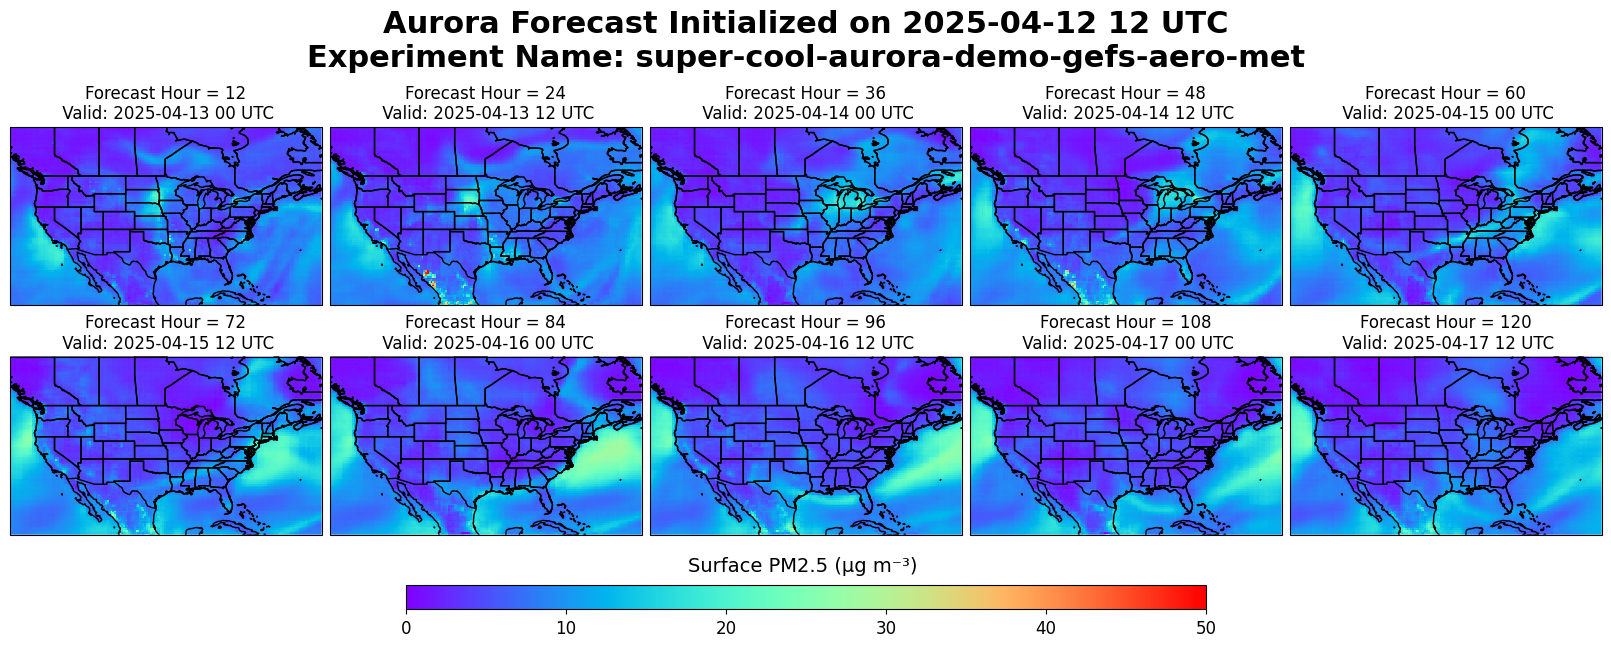

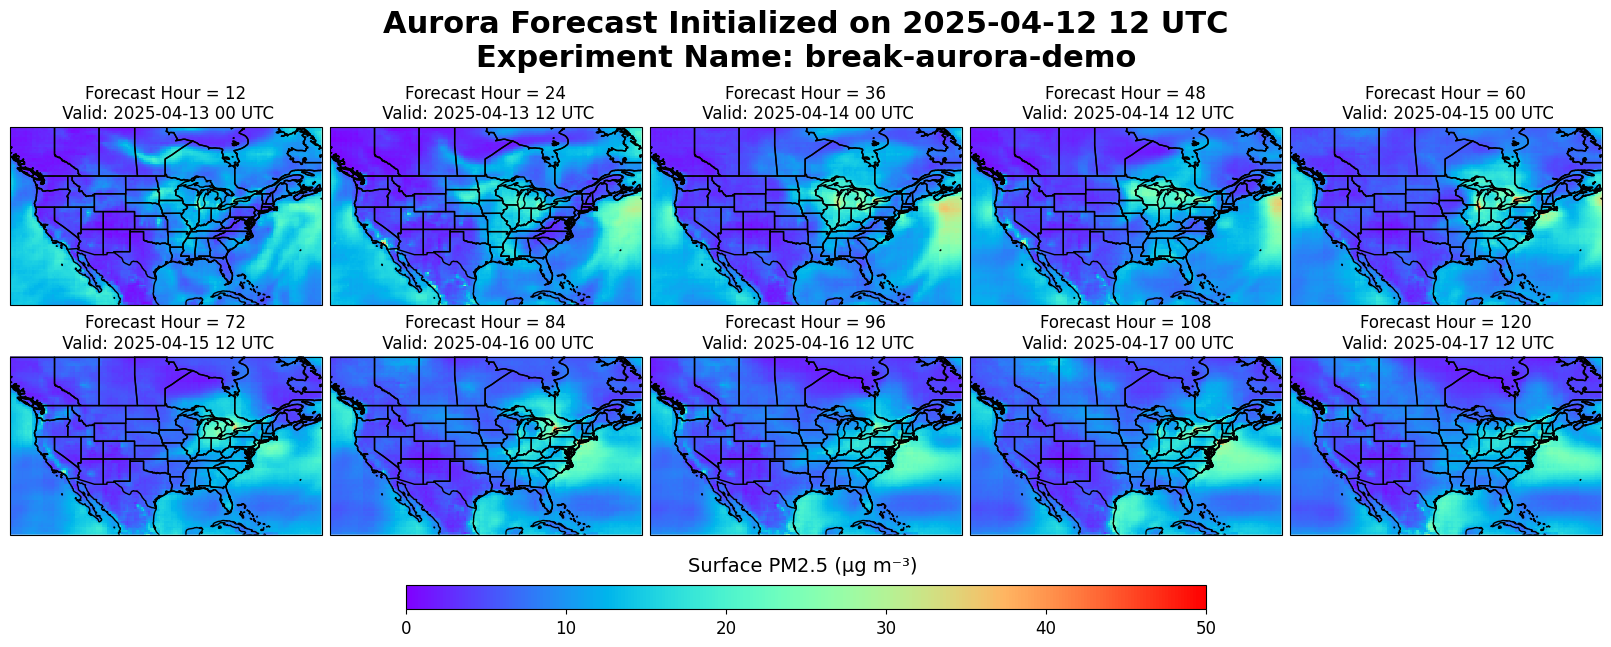

In [ ]:
for aurora_configuration in aurora_configurations.keys():

  # create variable for our configration parameters
  configure_params = aurora_configurations[aurora_configuration]


  print('Running Aurora for Experiment: '+aurora_configuration)
  print('\n')

  # check that we have sufficient data from CAMS
  # construct an array of valid forecast initialization times based on the available data from CAMS
  valid_cams_times_array = surf_vars_ds.valid_time.values

  # if a forecast date range is not specified, use all available cams data
  forecast_array = valid_cams_times_array.copy()


  print('== Model Configuration == ')
  print('Forecast lead time  = ', str(configure_params['lead_time_days']),' days')
  print('First forecast init = ', pd.to_datetime(forecast_array[0]).strftime('%Y-%m-%d %H UTC')[0])
  print('Last forecast init  = ', pd.to_datetime(forecast_array[-1]).strftime('%Y-%m-%d %H UTC')[0])
  print('Regridding GEFS method = ', configure_params['regrid_method'] )
  print('\n')
  print('== Chemistry and Meteorology ==')

  if configure_params['use_gefs_aero'] == True:
    print('Aerosol (PM1, PM2.5, PM10)  =  GEFS-Chem 0.25 deg')
  if configure_params['use_gefs_aero'] == False:
    print('Aerosol (PM1, PM2.5, PM10)  =  CAMS')

  if configure_params['use_gefs_met'] == True:
    print('Meteorology         =  GEFS-Control 0.5 deg')
  if configure_params['use_gefs_met'] == False:
    print('Meteorology         =  CAMS')


  for t0 in forecast_array:
    t12 =  (pd.to_datetime(pd.to_datetime(t0).strftime('%Y-%m-%d %H UTC')) - pd.Timedelta(hours=12))

    # check that the previous 12 hour forecast is present in our CAMS data; if not continue
    if t12[0].to_numpy() not in valid_cams_times_array:
        print('Cannot initialize forercast for '+pd.to_datetime(t0[0]).strftime('%Y-%m-%d %H UTC'))
        print('Missing previous 12-hour forecast!')
        print('Continuing to next hour... ')
        continue

    print('\n')
    print('== Preparing NetCDF Files ==')

    print('Initializing forecast '+pd.to_datetime(t0[0]).strftime('%Y-%m-%d %H UTC'))
    print('Previous 12-Hour forecast = '+pd.to_datetime(t12[0]).strftime('%Y-%m-%d %H UTC'))

    print('\n')


    surf_vars_dict = {} # append our surface variables here
    atmos_vars_dict = {} # append our atmosphere variables here

    # start by preparing our CAMS IC

    # generate data arrays with required initial, previous 12 hours (t12), and previous 24 hours (t24) of data
    # get index in CAMS data corresponding to our necessary forecast initialization (t0) and previous 12-hours (t12)
    idx_t0 = np.where(valid_cams_times_array == t0)[0].item()
    idx_t12 = np.where(valid_cams_times_array == t12[0].to_numpy())[0].item()

    # subset CAMS data to [t-12, t0]
    ds = surf_vars_ds.isel(forecast_reference_time=[idx_t12, idx_t0])
    da = atmos_vars_ds.isel(forecast_reference_time=[idx_t12, idx_t0])

    # redudant; but ensure we only get forecast hour 0 (aka analysis product)
    ds = ds.isel(forecast_period=0)
    da = da.isel(forecast_period=0)

    da = da.copy()
    ds = ds.copy()
    # assume we want all variables from CAMS initially, we were overrwrite with user defined configurations later

    # SURFACE VARIABELES
    surf_vars_dict['2t'] = ds['t2m'].copy()
    surf_vars_dict['10u'] = ds['u10'].copy()
    surf_vars_dict['10v'] = ds['v10'].copy()
    surf_vars_dict['msl'] = ds['msl'].copy()
    surf_vars_dict['pm1'] = ds['pm1'].copy()
    surf_vars_dict['pm2p5'] = ds['pm2p5'].copy()
    surf_vars_dict['pm10'] = ds['pm10'].copy()
    surf_vars_dict['tcco'] = ds['tcco'].copy()
    surf_vars_dict['tc_no'] = ds['tc_no'].copy()
    surf_vars_dict['tcno2'] = ds['tcno2'].copy()
    surf_vars_dict['gtco3'] = ds['gtco3'].copy()
    surf_vars_dict['tcso2'] = ds['tcso2'].copy()

    # ATMOSPHERE VARIABLES
    atmos_vars_dict['t'] = da['t'].copy()
    atmos_vars_dict['u'] = da['u'].copy()
    atmos_vars_dict['v'] = da['v'].copy()
    atmos_vars_dict['q'] = da['q'].copy()
    atmos_vars_dict['z'] = da['z'].copy()
    atmos_vars_dict['co'] = da['co'].copy()
    atmos_vars_dict['no'] = da['no'].copy()
    atmos_vars_dict['no2'] = da['no2'].copy()
    atmos_vars_dict['go3'] = da['go3'].copy()
    atmos_vars_dict['so2'] = da['so2'].copy()


    ## adding GEFS IC where necessary
    if configure_params['use_gefs_aero'] == True:
      # retrieve GEFS-Chem Analysis from Herbie

      # forecast initialization (t0)
      H_t0 = Herbie(
          pd.to_datetime(t0[0]).strftime('%Y-%m-%d %H'),
          model="gefs",
          product="chem.25",
          member="c00",
          fxx=00 # forecast hour
      )

      d_gefs_aero_pm1_t0 = approx_gefs_pm1(t0,verbose=False)
      dH_t0 = H_t0.inventory()
      search_strs = list( dH_t0[dH_t0['search_this'].str.contains('surface') & dH_t0['search_this'].str.contains('Total') ]['search_this'].values )
      d_gefs_aero_t0 = H_t0.xarray(search_strs[0]+'|'+search_strs[1])

      # forecast initialization (t12)
      H_t12 = Herbie(
          pd.to_datetime(t12[0]).strftime('%Y-%m-%d %H') ,
          model="gefs",
          product="chem.25",
          member="c00",
          fxx=00 # forecast hour
      )

      dH_t12 = H_t12.inventory()
      search_strs = list( dH_t12[dH_t12['search_this'].str.contains('surface') & dH_t12['search_this'].str.contains('Total') ]['search_this'].values )
      d_gefs_aero_t12 = H_t12.xarray(search_strs[0]+'|'+search_strs[1])

      d_gefs_aero_pm1_t12 = approx_gefs_pm1(t12,verbose=False)

      # combine GEFS datasets
      ds_gefs_aero = xr.concat([d_gefs_aero_t12, d_gefs_aero_t0], dim="time", coords='different', compat='equals')
      ds_gefs_aero = ds_gefs_aero.rename({'time':'forecast_reference_time'})
      ds_gefs_aero = ds_gefs_aero.rename({"pmtf": "pm2p5"})
      ds_gefs_aero = ds_gefs_aero.rename({"pmtc": "pm10"})

      # and for PM1
      ds_gefs_aero_pm1 = xr.concat([d_gefs_aero_pm1_t12, d_gefs_aero_pm1_t0], dim="time", coords='different', compat='equals')
      ds_gefs_aero_pm1 = ds_gefs_aero_pm1.rename({'time':'forecast_reference_time'})


      # order forecasts like CAM (IMPORTANT as Aurora uses this difference, without this the sign of the difference may be wrong)
      ds_gefs_aero = ds_gefs_aero.sortby('forecast_reference_time', ascending=True)
      ds_gefs_aero_pm1 = ds_gefs_aero_pm1.sortby('forecast_reference_time', ascending=True)

      # regrid GEFS to CAMS
      ds_gefs_aero = ds_gefs_aero.interp(longitude=ds.longitude, latitude=ds.latitude,
                                         method=configure_params['regrid_method'])
      ds_gefs_aero_pm1 = ds_gefs_aero_pm1.interp(longitude=ds.longitude, latitude=ds.latitude,
                                           method=configure_params['regrid_method'],kwargs={"fill_value": "extrapolate"})

      # PM unit conversion
      ds_gefs_aero['pm2p5'] = ds_gefs_aero['pm2p5']/1e9
      ds_gefs_aero['pm10'] = ds_gefs_aero['pm10']/1e9
      ds_gefs_aero_pm1['pm1'] = ds_gefs_aero_pm1['pm1']/1e9

      # now, append to surf_vars_dict to override CAMS
      surf_vars_dict['pm2p5'] = ds_gefs_aero['pm2p5'].copy()
      surf_vars_dict['pm10'] = ds_gefs_aero['pm10'].copy()
      surf_vars_dict['pm1'] = ds_gefs_aero_pm1['pm1'].copy()

    # build list of gefs atmos variables we need to retrieve
    if configure_params['use_gefs_met'] == True:
      gefs_atmos_variables = ['TMP','UGRD','VGRD','SPFH','HGT','PRMSL']

      # get GEFS-Control atmosphereic data
      #   recommend verbose set to False when retrieving files in bulk, use verbose for debugging
      dict_gefs_atmos_t0 = retrieve_gefs_atmos(t=t0, ensemble_member=configure_params['gefs_met_ensemble_member'], variables=gefs_atmos_variables, verbose=False)
      dict_gefs_atmos_t12 = retrieve_gefs_atmos(t=t12, ensemble_member=configure_params['gefs_met_ensemble_member'], variables=gefs_atmos_variables, verbose=False)

      # create surface (ds) and atmosphere (da) datasets
      ds_gefs_atmos = xr.concat([
                                dict_gefs_atmos_t12['ds_gefs_surf'],
                              dict_gefs_atmos_t0['ds_gefs_surf']]
                              , dim="time",coords='different',compat='equals')
      da_gefs_atmos = xr.concat([
                              dict_gefs_atmos_t12['da_gefs_atmos'],
                              dict_gefs_atmos_t0['da_gefs_atmos']]
                              , dim="time",coords='different',compat='equals')

      # match time dimension name to CAMS
      da_gefs_atmos = da_gefs_atmos.rename({'time':'forecast_reference_time'})
      ds_gefs_atmos = ds_gefs_atmos.rename({'time':'forecast_reference_time'})

      # sort time dimension to ascending
      da_gefs_atmos = da_gefs_atmos.sortby('forecast_reference_time', ascending=True)
      ds_gefs_atmos = ds_gefs_atmos.sortby('forecast_reference_time', ascending=True)


      # regrid GEFS-Control to CAMS (0.5 to 0.44)
      ds_gefs_atmos = ds_gefs_atmos.interp(longitude=ds.longitude, latitude=ds.latitude,
                                           method=configure_params['regrid_method'],kwargs={"fill_value": "extrapolate"})
      da_gefs_atmos = da_gefs_atmos.interp(longitude=da.longitude, latitude=da.latitude, pressure_level=da.pressure_level,
                                           method=configure_params['regrid_method'],kwargs={"fill_value": "extrapolate"})

      if configure_params['use_gefs_met']== True:
        # geopotential height to geopotential conversion
        da_gefs_atmos['z'] = da_gefs_atmos['gh']*9.80665

        # append to surf_vars_dict to override CAMS
        surf_vars_dict['2t'] = ds_gefs_atmos['t2m'].copy()
        surf_vars_dict['10u'] = ds_gefs_atmos['u10'].copy()
        surf_vars_dict['10v'] = ds_gefs_atmos['v10'].copy()
        surf_vars_dict['msl'] = ds_gefs_atmos['prmsl'].copy()

        # append to atmos_vars_dict to override CAMS
        atmos_vars_dict['t'] = da_gefs_atmos['t'].copy()
        atmos_vars_dict['u'] = da_gefs_atmos['u'].copy()
        atmos_vars_dict['v'] = da_gefs_atmos['v'].copy()
        atmos_vars_dict['q'] = da_gefs_atmos['q'].copy()
        atmos_vars_dict['z'] = da_gefs_atmos['z'].copy()

    # Apply Sensitivity Test Configurations
    # remove specified atmosphere vars
    for variable in configure_params['remove_atmos_variables']:
      del atmos_vars_dict[variable]

    # remove specified surface vars
    for variable in configure_params['remove_surf_variables']:
      del surf_vars_dict[variable]

    # construct torches
    # SURFACE
    surf_vars_torch = {}
    for surf_var in surf_vars_dict.keys():
      surf_vars_torch[surf_var] = torch.from_numpy(surf_vars_dict[surf_var].values[None])
    # ATMOSPHERE
    atmos_vars_torch = {}
    for atmos_var in atmos_vars_dict.keys():
      atmos_vars_torch[atmos_var] = torch.from_numpy(atmos_vars_dict[atmos_var].values[None])


    print('--PRE-PROCESSING COMPLETE!--')
    print('\n')
    print('Final surface variables = ', list(surf_vars_torch.keys()))
    print('Final atmospheric variables = ', list(atmos_vars_torch.keys()))
    print('\n')

    print('== Constructing Batches ==')
    # Now construct a batch!
    batch = Batch(
      surf_vars=surf_vars_torch,
      static_vars={k: torch.from_numpy(v) for k, v in static_vars.items()},
      atmos_vars=atmos_vars_torch,
      metadata=Metadata(
          lat=torch.from_numpy(da.latitude.values),
          lon=torch.from_numpy(da.longitude.values),
          # Converting to `datetime64[s]` ensures that the output of `tolist()` gives
          # `datetime.datetime`s.
          time=(da.valid_time.values.astype("datetime64[s]").tolist()[-1],),
          atmos_levels=tuple(int(level) for level in da.pressure_level.values),
      ),)



    print('Batch successfully created.')
    print('\n')
    print('== Running Aurora ==')

    # Now, run Aurora!
    model = model.to("cuda")
    with torch.inference_mode():
      print('Inference mode running.. ')
      predictions = [pred.to("cpu") for pred in rollout(model, batch, steps=(((configure_params['lead_time_days'])*2)))] # 2 forecats (0Z, 12Z) per day,

    model = model.to("cpu")
    print('Aurora forecast completed.')
    print('\n')

    # create xarray datasets and plot!
    fig = plt.figure(figsize=(16, 12),layout='compressed')
    gs = gridspec.GridSpec(2, 5, figure=fig, wspace=0.02, hspace=0.01)
    i = 0
    for individual_forecast_hour in range(len(predictions)):
          aurora_forecast = predictions[individual_forecast_hour]
          aurora_lat = aurora_forecast.metadata.lat
          aurora_lon = aurora_forecast.metadata.lon

          aurora_valid = pd.to_datetime(aurora_forecast.metadata.time)

          # construct dataset with relevant fields; modify with whatever variables are needed for validation
          aurora_output_xr = xr.Dataset(
              {
              "pm25": (('lat','lon'), aurora_forecast.surf_vars["pm2p5"][0, 0].numpy()*1e9), # convert to micrograms per meter cubed
              },

              coords={
                  "lat": aurora_lat,
                  "lon": aurora_lon,
                  "atmos_levels": np.array(list(aurora_forecast.metadata.atmos_levels)),
                  "step": (aurora_forecast.metadata.rollout_step*12),
                  "time": t0,
                  "valid_time": aurora_valid.item(),
                  "rollout": aurora_forecast.metadata.rollout_step
              },
          )

          aurora_output_xr = aurora_output_xr.assign_coords(
              lon=((aurora_output_xr.lon + 180) % 360) - 180) # match long dim to Airnow (-180 to 180
          aurora_output_xr = aurora_output_xr.sortby('lon') # Ensure 'lon' is sorted

          axs = fig.add_subplot(gs[i], projection=ccrs.PlateCarree())
          mesh = (aurora_output_xr['pm25']).plot.pcolormesh(ax=axs, x='lon', y='lat',vmin=0, vmax=50,cmap='rainbow',
                                              transform=ccrs.PlateCarree(), add_colorbar=False)


          axs.set_title('Forecast Hour = '+str((aurora_forecast.metadata.rollout_step*12))+'\n Valid: '+str(aurora_valid.item().strftime('%Y-%m-%d %H UTC')))

          axs.set_extent([-130, -60, 20, 60], crs=ccrs.PlateCarree()) # set domain to CONUS
          axs.add_feature(cfeature.COASTLINE) # add coastline basemap
          axs.add_feature(cfeature.STATES) # add states outlines
          axs.set_aspect('equal')

          i += 1

    cbar_ax = fig.add_axes([0.25, 0.25, 0.5, 0.02]) # left, bottom, width, height
    fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal')
    cbar_ax.set_title('Surface PM2.5 (µg m⁻³) ', fontsize=14, pad=10)
    cbar_ax.tick_params(labelsize=12)

    fig.suptitle('Aurora Forecast Initialized on '+pd.to_datetime(t0[0]).strftime('%Y-%m-%d %H UTC')+'\nExperiment Name: '+aurora_configuration+'',
                  fontweight='bold',fontsize=22, y=0.75, x=0.5)

    plt.savefig(str(download_path)+'/aurora-forecast-'+aurora_configuration+'.png',
                  dpi=100,bbox_inches='tight')

    # save a copy of our aurora configuration to a .yaml file
    with open(str(download_path)+'/aurora-config-'+aurora_configuration+'.yaml', 'w') as file:
      yaml.dump(aurora_configurations[aurora_configuration], file, default_flow_style=False, sort_keys=False)
      print('Exported .yaml file to ', str(download_path)+'/aurora-config-'+aurora_configuration+'.yaml')
